In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" 

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from transformers import AutoTokenizer, TFBertModel
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split

# CONFIGURACIÓN (mis rutas a memes y csv con datos)
RUTA_CSV = "/home/esebas/Escritorio/Sebas/IA SAMSUNG/PROYECTO/datasets/dataset_final_QWEN_WIP.csv"
RUTA_IMAGENES = "/home/esebas/Escritorio/Sebas/IA SAMSUNG/PROYECTO/extraccion memes/ALL MEMES"
MAX_LEN = 160
BATCH_SIZE = 12 #Subir o bajar según GPU (en mi caso rtx 4050 como referencia)
LR_FINAL = 1e-5  # Muy lento para mayor precisión (quiero un entrenamiento algo más fino)

# 1. PREPARACIÓN DE DATOS
df = pd.read_csv(RUTA_CSV)
df['extracted_text'] = df['extracted_text'].fillna('')
df['description_es_new'] = df['description_es_new'].fillna('')

#Concatenamos el texto extraído del meme en cuestión a la descripción del mismo generada por QWEN (LLM)
df['text_final'] = "MEME: " + df['extracted_text'] + " [SEP] ESCENA: " + df['description_es_new']

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['harmless']) #Estratifico para que haya misma proporcion en train y val

tokenizer = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased') #Modelo BERT, pero para español (BETO)
t_train = tokenizer(df_train['text_final'].tolist(), padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="tf")
t_val = tokenizer(df_val['text_final'].tolist(), padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors="tf")

2026-02-01 22:25:19.287622: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/esebas/tf4050/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
I0000 00:00:1769981126.672004   20453 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [2]:
# CAPA DE DATA AUGMENTATION (para evitar overfitting principalmente)
data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.1), #Rotación leve
    layers.RandomZoom(0.1), #Zoom leve
    layers.RandomBrightness(0.1) #Ajuste brillo leve
])

def procesar_v3(path, ids, mask, label, augment=False):
    file = tf.io.read_file(path)
    img = tf.image.decode_jpeg(file, channels=3)
    img = tf.image.resize(img, (224, 224))
    if augment:
        img = data_aug(tf.expand_dims(img, 0))[0]
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return ({"img_input": img, "ids_input": ids, "mask_input": mask}, label)

train_ds = tf.data.Dataset.from_tensor_slices((
    [os.path.join(RUTA_IMAGENES, m) for m in df_train['meme_id']],
    t_train['input_ids'], t_train['attention_mask'],
    df_train['harmless'].values.astype('float32')
)).map(lambda p, i, m, l: procesar_v3(p, i, m, l, augment=True), num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    [os.path.join(RUTA_IMAGENES, m) for m in df_val['meme_id']],
    t_val['input_ids'], t_val['attention_mask'],
    df_val['harmless'].values.astype('float32')
)).map(lambda p, i, m, l: procesar_v3(p, i, m, l, augment=False), num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [3]:
# 3. ARQUITECTURA (para v3)
def build_v3():
    # RAMA VISUAL (EfficientNet)
    img_in = layers.Input(shape=(224, 224, 3), name='img_input')
    base_cnn = EfficientNetB0(weights='imagenet', include_top=False)
    base_cnn.trainable = True
    for layer in base_cnn.layers[:-30]: layer.trainable = False
    x_i = layers.GlobalAveragePooling2D()(base_cnn(img_in))
    x_i = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x_i)
    x_i = layers.BatchNormalization()(x_i)
    x_i = layers.Dropout(0.5)(x_i)

    # RAMA TEXTUAL (BETO)
    ids_in = layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='ids_input')
    mask_in = layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='mask_input')
    base_bert = TFBertModel.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')
    base_bert.trainable = True
    for layer in base_bert.bert.encoder.layer[:-4]: layer.trainable = False
    bert_out = base_bert(ids_in, attention_mask=mask_in)[1]
    x_t = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(bert_out)
    x_t = layers.BatchNormalization()(x_t)
    x_t = layers.Dropout(0.5)(x_t)

    # FUSIÓN (Concatenación + Producto)
    # El producto parece que captura mejor la relación entre texto e imagen que una simple concatenación
    # Realizo esta fusión modificada, ya que en la primera versión (v1) noté que el modelo no captaba bien dicha relación imagen-texto
    inter = layers.Multiply()([x_i, x_t])
    concat = layers.Concatenate()([x_i, x_t, inter])
    
    # Bloque de decisión
    z = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.02))(concat)
    z = layers.Dropout(0.5)(z)
    output = layers.Dense(1, activation='sigmoid')(z)

    model = models.Model(inputs=[img_in, ids_in, mask_in], outputs=output)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR_FINAL),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_v3()

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on

In [4]:
# 4. ENTRENAMIENTO
y_t = df_train['harmless'].values
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_t), y=y_t)
weights_dict = dict(enumerate(weights))

call_list = [
    callbacks.ModelCheckpoint('modelo_MEMES4GOOD_v3.keras', save_best_only=True, monitor='val_auc', mode='max'),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=30, class_weight=weights_dict, callbacks=call_list)

Epoch 1/30


E0000 00:00:1769981333.623268   20453 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-01 22:28:55.803200: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-01 22:28:57.328206: I external/local_xla/xla/service/service.cc:163] XLA service 0x797655a798b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 22:28:57.328228: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-01 22:28:57.340203: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769981337.406532   20699 device_compiler.h:196] Compiled cluster using XLA

454/454 [==============================] - ETA: 0s - loss: 16.5249 - accuracy: 0.5750 - auc: 0.5559

/home/esebas/tf4050/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


454/454 [==============================] - 141s 263ms/step - loss: 16.5249 - accuracy: 0.5750 - auc: 0.5559 - val_loss: 15.8642 - val_accuracy: 0.6544 - val_auc: 0.6800 - lr: 1.0000e-05
Epoch 2/30
454/454 [==============================] - 117s 258ms/step - loss: 15.8112 - accuracy: 0.6256 - auc: 0.6421 - val_loss: 15.2993 - val_accuracy: 0.7015 - val_auc: 0.7601 - lr: 1.0000e-05
Epoch 3/30
454/454 [==============================] - 117s 259ms/step - loss: 15.2296 - accuracy: 0.6406 - auc: 0.6833 - val_loss: 14.7524 - val_accuracy: 0.7375 - val_auc: 0.8006 - lr: 1.0000e-05
Epoch 4/30
454/454 [==============================] - 118s 259ms/step - loss: 14.6431 - accuracy: 0.6864 - auc: 0.7445 - val_loss: 14.2364 - val_accuracy: 0.7529 - val_auc: 0.8264 - lr: 1.0000e-05
Epoch 5/30
454/454 [==============================] - 118s 260ms/step - loss: 14.1075 - accuracy: 0.7035 - auc: 0.7718 - val_loss: 13.7460 - val_accuracy: 0.7522 - val_auc: 0.8396 - lr: 1.0000e-05
Epoch 6/30
454/454 [======

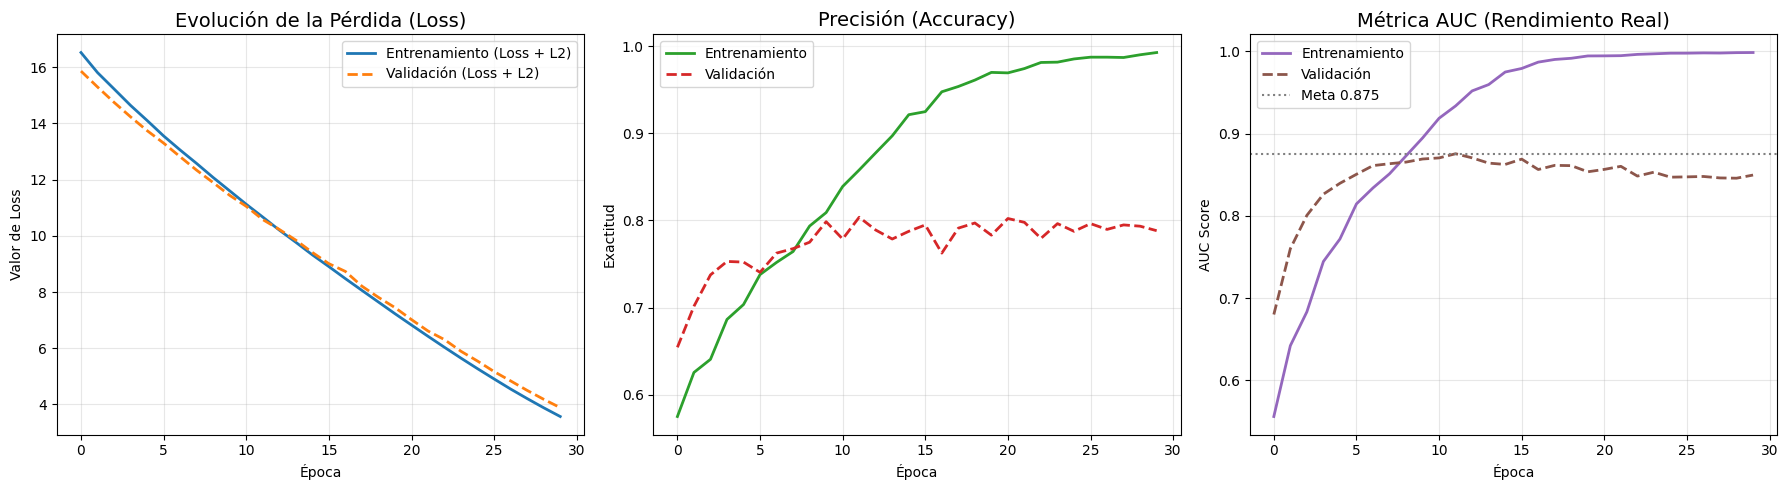

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Loss + L2)', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Loss + L2)', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)', fontsize=14)
plt.xlabel('Época')
plt.ylabel('Valor de Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento', color='#2ca02c', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación', color='#d62728', linestyle='--', linewidth=2)
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Entrenamiento', color='#9467bd', linewidth=2)
plt.plot(history.history['val_auc'], label='Validación', color='#8c564b', linestyle='--', linewidth=2)
plt.axhline(y=0.875, color='gray', linestyle=':', label='Meta 0.875')
plt.title('Métrica AUC (Rendimiento Real)', fontsize=14)
plt.xlabel('Época')
plt.ylabel('AUC Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficas_entrenamiento_V3.png') 
plt.show()